> ⭐ **EXTRA (optional, just for information).** This notebook implements the algorithm **from scratch** to show what happens inside. The core lesson for this day is in notebooks 01–02; teach that first and use this one only for curious students.

# Day 35 (3/3) — Ridge from Scratch

Three ways to compute Ridge, each checked against scikit-learn:

| Method | When it is useful |
|---|---|
| 1. Simple formula for **one feature** | Understanding: see exactly where α enters |
| 2. **Closed form** (normal equation) for many features | Exact answer in one step, for moderate numbers of features |
| 3. **Gradient descent** | Very large datasets, and the basis of SGD / neural networks |

> 📖 Derivations: [`theory.md`](theory.md) §5

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_regression, load_diabetes
from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
plt.rcParams.update({'figure.dpi': 100, 'axes.grid': True, 'grid.alpha': 0.3,
                     'axes.spines.top': False, 'axes.spines.right': False})

---
## 1. One feature: the slope formula

For simple linear regression, the least-squares slope is $m = \dfrac{\sum (x_i-\bar x)(y_i-\bar y)}{\sum (x_i-\bar x)^2}$.

Ridge adds α to the **denominator**:

$$
m_{\text{ridge}} = \frac{\sum (x_i-\bar x)(y_i-\bar y)}{\sum (x_i-\bar x)^2 + \alpha}, \qquad b = \bar y - m\,\bar x
$$

A bigger denominator means a smaller slope. That is the whole shrinking effect, in one formula.

> ✍️ **Core code: learn this.** A minimal Ridge class for one feature.

In [2]:
class SimpleRidge:
    def __init__(self, alpha=1.0):
        self.alpha = alpha

    def fit(self, X, y):
        x = X.ravel()
        x_mean, y_mean = x.mean(), y.mean()
        num = np.sum((x - x_mean) * (y - y_mean))
        den = np.sum((x - x_mean) ** 2)
        self.m = num / (den + self.alpha)
        self.b = y_mean - self.m * x_mean
        return self

    def predict(self, X):
        return self.m * X.ravel() + self.b

In [3]:
X1, y1 = make_regression(n_samples=100, n_features=1, noise=20, random_state=13)

for alpha in [0, 10, 100]:
    ours = SimpleRidge(alpha).fit(X1, y1)
    sk = Ridge(alpha=alpha).fit(X1, y1)
    print(f"alpha={alpha:<4} ours: m={ours.m:7.3f} b={ours.b:7.3f}   |   sklearn: m={sk.coef_[0]:7.3f} b={sk.intercept_:7.3f}")

alpha=0    ours: m= 27.828 b= -2.295   |   sklearn: m= 27.828 b= -2.295
alpha=10   ours: m= 24.955 b= -2.127   |   sklearn: m= 24.955 b= -2.127
alpha=100  ours: m= 12.934 b= -1.425   |   sklearn: m= 12.934 b= -1.425


Identical to scikit-learn. ✅

---
## 2. Many features: the closed form

Linear regression's normal equation is $w = (X^\top X)^{-1}X^\top y$. Ridge adds $\alpha I$:

$$
w = (X^\top X + \alpha I)^{-1} X^\top y
$$

We add a column of 1s for the intercept and set the first diagonal entry of $I$ to **0**, because the intercept is **not** penalised.

> Bonus: $X^\top X + \alpha I$ is always invertible for α > 0, even when features are perfectly correlated.
> Ridge was originally invented for exactly this reason.

> ✍️ **Core code: learn this.** Ridge in one line of linear algebra.

In [4]:
class RidgeClosedForm:
    def __init__(self, alpha=0.1):
        self.alpha = alpha

    def fit(self, X, y):
        Xb = np.insert(X, 0, 1, axis=1)            # add intercept column
        I = np.identity(Xb.shape[1])
        I[0, 0] = 0                                # do not penalise the intercept
        w = np.linalg.solve(Xb.T @ Xb + self.alpha * I, Xb.T @ y)
        self.intercept_, self.coef_ = w[0], w[1:]
        return self

    def predict(self, X):
        return X @ self.coef_ + self.intercept_

In [5]:
X, y = load_diabetes(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=4)

ours = RidgeClosedForm(alpha=0.1).fit(X_train, y_train)
sk = Ridge(alpha=0.1).fit(X_train, y_train)

print("ours    R²:", round(r2_score(y_test, ours.predict(X_test)), 6), " coef:", ours.coef_.round(2))
print("sklearn R²:", round(r2_score(y_test, sk.predict(X_test)), 6), " coef:", sk.coef_.round(2))

ours    R²: 0.469313  coef: [  44.02 -241.69  452.99  332.04  -76.34  -68.52 -164.99  149.97  431.61
   58.52]
sklearn R²: 0.469313  coef: [  44.02 -241.69  452.99  332.04  -76.34  -68.52 -164.99  149.97  431.61
   58.52]


Identical again. ✅ (We use `np.linalg.solve` instead of `np.linalg.inv`: it gives the same result but is faster and more numerically stable.)

---
## 3. Gradient descent

Gradient of the Ridge loss $\lVert y - Xw\rVert^2 + \alpha\lVert w\rVert^2$ (intercept not penalised):

$$
\nabla = 2\big(X^\top X w - X^\top y + \alpha\, I' w\big)
$$

The constant 2 is absorbed into the learning rate. Update: $w \leftarrow w - \eta\,\nabla$.

> ✍️ **Core code: learn this.** Same loss, solved step by step.

In [6]:
class RidgeGD:
    def __init__(self, alpha=0.1, learning_rate=0.005, epochs=20000):
        self.alpha = alpha
        self.learning_rate = learning_rate
        self.epochs = epochs

    def fit(self, X, y):
        Xb = np.insert(X, 0, 1, axis=1)
        I = np.identity(Xb.shape[1])
        I[0, 0] = 0                                       # intercept not penalised
        w = np.ones(Xb.shape[1])
        self.history = []
        for _ in range(self.epochs):
            gradient = Xb.T @ Xb @ w - Xb.T @ y + self.alpha * (I @ w)
            w = w - self.learning_rate * gradient
            self.history.append(w.copy())
        self.intercept_, self.coef_ = w[0], w[1:]
        return self

    def predict(self, X):
        return X @ self.coef_ + self.intercept_

In [7]:
gd = RidgeGD(alpha=0.1).fit(X_train, y_train)

print("GD      R²:", round(r2_score(y_test, gd.predict(X_test)), 6), " coef:", gd.coef_.round(2))
print("sklearn R²:", round(r2_score(y_test, sk.predict(X_test)), 6), " coef:", sk.coef_.round(2))

GD      R²: 0.469313  coef: [  44.02 -241.69  452.99  332.04  -76.34  -68.52 -164.99  149.97  431.61
   58.52]
sklearn R²: 0.469313  coef: [  44.02 -241.69  452.99  332.04  -76.34  -68.52 -164.99  149.97  431.61
   58.52]


After enough epochs, gradient descent reaches the same answer. **How many is "enough"?**

> 🎨 **Visualization only. You do not need to learn this code.** It just draws the picture below. Run it and focus on the plot. *(The code is collapsed; click it to expand if you are curious.)*

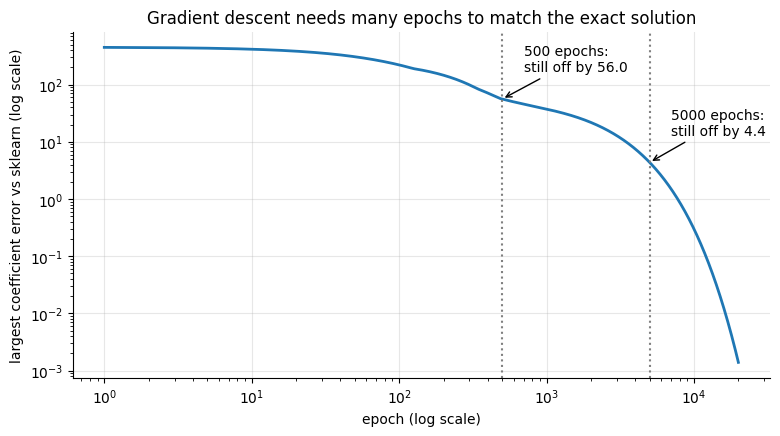

In [8]:
history = np.array(gd.history)[:, 1:]
gap = np.abs(history - sk.coef_).max(axis=1)

plt.figure(figsize=(9, 4.5))
plt.plot(np.arange(1, len(gap) + 1), gap, linewidth=2)
for e in [500, 5000]:
    plt.axvline(e, color='gray', linestyle=':')
    plt.annotate(f'{e} epochs:\nstill off by {gap[e - 1]:.1f}', (e, gap[e - 1]), xytext=(e * 1.4, gap[e - 1] * 3),
                 arrowprops=dict(arrowstyle='->'))
plt.xscale('log')
plt.yscale('log')
plt.xlabel('epoch (log scale)')
plt.ylabel('largest coefficient error vs sklearn (log scale)')
plt.title('Gradient descent needs many epochs to match the exact solution')
plt.show()

With only 500 epochs the coefficients are still far from the true Ridge solution, a common source of
"my from-scratch result doesn't match sklearn". The slow part is features that are highly correlated with each other
(e.g. `s1` and `s2` here): the loss surface is a long, narrow valley, and gradient descent creeps along it.

---
## Key takeaways
- Ridge = least squares + α on the **diagonal**: $(X^\top X + \alpha I)^{-1}X^\top y$. For one feature: α in the denominator.
- The intercept is **never** penalised.
- Closed form is exact; gradient descent gets there iteratively. Check convergence before trusting it.
- In practice: `sklearn.linear_model.Ridge` (or `SGDRegressor(penalty='l2')` for huge datasets).

➡️ **Next day:** Lasso regression: what if the penalty could **remove** useless features entirely?